# 01: Import

## 01-1: Library

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


import joblib

from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


from math import log

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 01-2: Data

In [65]:
data_path = '/content/drive/MyDrive/epoch_datathon/data'

### Case 1: 14일 기준

In [66]:
df_subset_14 = pd.read_csv(f'{data_path}/df_fin_14.csv')
df_subset_28 = pd.read_csv(f'{data_path}/df_fin_28.csv')
df_subset_28.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3350 entries, 0 to 3349
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   budget               3350 non-null   float64
 1   id                   3350 non-null   int64  
 2   popularity           3350 non-null   float64
 3   release_date         3350 non-null   object 
 4   revenue              3350 non-null   float64
 5   runtime              3350 non-null   float64
 6   title                3350 non-null   object 
 7   vote_average         3350 non-null   float64
 8   vote_count           3350 non-null   float64
 9   cast_1_popularity    3350 non-null   float64
 10  cast_2_popularity    3350 non-null   float64
 11  director_popularity  3350 non-null   float64
 12  bb_diff_28           3350 non-null   int64  
 13  bb_effect_28         3350 non-null   int64  
dtypes: float64(9), int64(3), object(2)
memory usage: 366.5+ KB


- 데이터 새로 뽑히는 거 보고, 필요하면 쓸 코드

### Case 2: 28일 기준

---

# 02: Define Function

## 02-1: 계산 함수 정의

### 계산 함수 1: Exponential Decay Function(지수 감쇠 함수)
> bb_dist의 비선형 변환을 위한 함수

In [67]:
# Exponential Decay Function
def exponential_decay(x, A, decay_rate):
    return A * np.exp(-decay_rate * x)

### 계산 함수 2: AIC, BIC 계산 정의

In [68]:
# AIC와 BIC 계산 함수
def calculate_aic(n, mse, num_params):
    return n * np.log(mse) + 2 * num_params

def calculate_bic(n, mse, num_params):
    return n * np.log(mse) + np.log(n) * num_params

## 02-2 모델링 함수 정의

### 모델링 함수 1: Data Split

In [69]:
# 데이터 분할 함수
def split_data(df, target_column, test_size=0.2, random_state=42):
    """
    Split the data into training and testing sets.

    Args:
        df: DataFrame to be split
        target_column: the name of the target column (label)
        test_size: the proportion of the dataset to include in the test split
        random_state: seed for reproducibility

    Returns:
        X_train, X_test, y_train, y_test: training and testing sets
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    return X_train, X_test, y_train, y_test

### 모델링 함수: Scaling

```python
# 사용 예시
# 연속형 변수 컬럼명 리스트 (예시)
columns_to_scale = ['budget', 'popularity', 'runtime', 'vote_average', 'cast_1_popularity']

# 스케일링 함수 적용
X_train_scaled, X_test_scaled = scale_selected_columns(X_train, X_test, columns_to_scale)
```

In [70]:
from sklearn.preprocessing import StandardScaler

# 지정한 컬럼에 대해서만 스케일링하는 함수
def scale_selected_columns(X_train, X_test, columns_to_scale):
    # 스케일링하지 않을 나머지 컬럼들
    columns_not_to_scale = [col for col in X_train.columns if col not in columns_to_scale]

    # 연속형 변수에 대해 StandardScaler 적용
    scaler = StandardScaler()

    # 연속형 변수에만 스케일링 적용
    X_train_scaled_cont = pd.DataFrame(scaler.fit_transform(X_train[columns_to_scale]), columns=columns_to_scale, index=X_train.index)
    X_test_scaled_cont = pd.DataFrame(scaler.transform(X_test[columns_to_scale]), columns=columns_to_scale, index=X_test.index)

    # 더미 변수는 그대로 유지
    X_train_not_scaled = X_train[columns_not_to_scale]
    X_test_not_scaled = X_test[columns_not_to_scale]

    # 스케일링된 연속형 변수와 스케일링되지 않은 더미 변수 결합
    X_train_scaled = pd.concat([X_train_scaled_cont, X_train_not_scaled], axis=1)
    X_test_scaled = pd.concat([X_test_scaled_cont, X_test_not_scaled], axis=1)

    return X_train_scaled, X_test_scaled

### 모델링 함수 2: Evaluate_model
- elastic net, ridge, lasso 중 선택한 모델에 대한 모델링 및 성능 평가
- 스케일링된 X를 인풋으로 줘야 함

In [71]:
def evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, model_type='elastic_net', alpha=1.0, l1_ratio=0.5):
    # 모델 타입에 따른 모델 설정
    if model_type == 'elastic_net':
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
    elif model_type == 'ridge':
        model = Ridge(alpha=alpha, max_iter=10000, random_state=42)
    elif model_type == 'lasso':
        model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    else:
        raise ValueError("Invalid model_type. Choose from 'elastic_net', 'ridge', or 'lasso'.")

    # 학습
    model.fit(X_train_scaled, y_train)

    # 테스트 데이터로 예측
    y_pred = model.predict(X_test_scaled)

    # 성능 평가
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    num_params = X_train_scaled.shape[1]

    aic = calculate_aic(n, mse, num_params)
    bic = calculate_bic(n, mse, num_params)

    return mse, r2, aic, bic

### 모델링 함수 2: find_best_model

In [72]:
# 최적 모델 찾기 함수 (모든 모델 성능 출력 추가)
def find_best_model(X_train_scaled, X_test_scaled, y_train, y_test):
    best_mse = float('inf')
    best_model = None
    best_model_name = None
    best_metrics = None

    # 모델과 하이퍼파라미터 설정
    models = [
        (ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000, random_state=42), 'ElasticNet_0.5_0.7'),
        (ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, random_state=42), 'ElasticNet_1.0_0.5'),
        (Ridge(alpha=1.0, max_iter=10000, random_state=42), 'Ridge_1.0'),
        (Ridge(alpha=0.1, max_iter=10000, random_state=42), 'Ridge_0.1'),
        (Lasso(alpha=0.1, max_iter=10000, random_state=42), 'Lasso_0.1'),
        (Lasso(alpha=1.0, max_iter=10000, random_state=42), 'Lasso_1.0')
    ]

    # 성능 결과 저장 리스트
    results = []

    # 모델을 반복하면서 성능 평가
    for model, model_name in models:
        mse, r2, aic, bic, model_name, trained_model = evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, model, model_name)

        # MSE 기준으로 최적 모델 선택
        if mse < best_mse:
            best_mse = mse
            best_model = trained_model
            best_model_name = model_name
            best_metrics = {'MSE': mse, 'R²': r2, 'AIC': aic, 'BIC': bic}

        # 모든 모델의 성능을 리스트에 저장
        results.append({
            'Model': model_name,
            'MSE': mse,
            'R²': r2,
            'AIC': aic,
            'BIC': bic
        })

    # 성능 결과를 데이터프레임으로 변환하고 MSE 기준으로 정렬
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='MSE')

    # 결과 출력
    import ace_tools as tools; tools.display_dataframe_to_user(name="Model Performance", dataframe=results_df)

    # 최적 모델 출력
    print(f"Best Model: {best_model_name}")
    print(f"Metrics: {best_metrics}")

    # 최적 모델 저장
    joblib.dump(best_model, f"{best_model_name}.pkl")
    print(f"Model saved as {best_model_name}.pkl")

    return best_model, best_metrics, results_df

# 사용 예시
# best_model, best_metrics, results_df = find_best_model(X_train_scaled, X_test_scaled, y_train, y_test)

---

# 03: Modeling

## Phase 0: EDF를 고려하지 않은 선형적인 모델링

In [73]:
df =  df_subset_28.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3350 entries, 0 to 3349
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   budget               3350 non-null   float64
 1   id                   3350 non-null   int64  
 2   popularity           3350 non-null   float64
 3   release_date         3350 non-null   object 
 4   revenue              3350 non-null   float64
 5   runtime              3350 non-null   float64
 6   title                3350 non-null   object 
 7   vote_average         3350 non-null   float64
 8   vote_count           3350 non-null   float64
 9   cast_1_popularity    3350 non-null   float64
 10  cast_2_popularity    3350 non-null   float64
 11  director_popularity  3350 non-null   float64
 12  bb_diff_28           3350 non-null   int64  
 13  bb_effect_28         3350 non-null   int64  
dtypes: float64(9), int64(3), object(2)
memory usage: 366.5+ KB


In [74]:
df_modeling = df.drop(columns=['title', 'id', 'release_date'])
df_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3350 entries, 0 to 3349
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   budget               3350 non-null   float64
 1   popularity           3350 non-null   float64
 2   revenue              3350 non-null   float64
 3   runtime              3350 non-null   float64
 4   vote_average         3350 non-null   float64
 5   vote_count           3350 non-null   float64
 6   cast_1_popularity    3350 non-null   float64
 7   cast_2_popularity    3350 non-null   float64
 8   director_popularity  3350 non-null   float64
 9   bb_diff_28           3350 non-null   int64  
 10  bb_effect_28         3350 non-null   int64  
dtypes: float64(9), int64(2)
memory usage: 288.0 KB


In [75]:
# df.columns
# 연속형 변수 컬럼명 리스트
columns_to_scale_14 = ['budget',
                        'popularity',
                        # 'revenue', # target
                        'runtime',
                        'vote_average', 'vote_count',
                        'cast_1_popularity', 'cast_2_popularity', 'director_popularity',
                        'bb_diff_14',
                        # 'bb_effect_14'
                       ]

columns_to_scale_28 = ['budget',
                        'popularity',
                        # 'revenue', # target
                        'runtime',
                        'vote_average', 'vote_count',
                        'cast_1_popularity', 'cast_2_popularity', 'director_popularity',
                        'bb_diff_28',
                        # 'bb_effect_28'
                       ]

In [76]:
X_train, X_test, y_train, y_test = split_data(df=df_modeling, target_column='revenue', test_size=0.2, random_state=42)

# 스케일링 함수 적용 (Case에 따라, columns_to_scale 수정 필수)
X_train_scaled, X_test_scaled = scale_selected_columns(X_train, X_test, columns_to_scale = columns_to_scale_28)

# 기본 모델
mse, r2, aic, bic =  evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, model_type='elastic_net', alpha=1.0, l1_ratio=0.5)

# 결과 출력
print("ElasticNet 기본 모델 결과:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")
print(f"AIC: {aic}")
print(f"BIC: {bic}")

ElasticNet 기본 모델 결과:
Mean Squared Error (MSE): 5505561821044915.0
R-squared (R^2): 0.769327593565883
AIC: 24303.838594974713
BIC: 24348.911372098562


## Phase1: EDF를 고려한 모델링

### Phase1-0: EDF 모델링 함수 및 하이퍼파라미터 정의

In [77]:
# 다양한 A 값과 decay_rate 값을 실험하여 모델 성능을 비교하는 함수
def evaluate_exponential_decay(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    results = []

    for A in A_values:
        for decay_rate in decay_rate_values:
            # 선택한 feature에 대해 Exponential decay 변환 적용
            feature_train_transformed = exponential_decay(X_train[feature].values, A, decay_rate)
            feature_test_transformed = exponential_decay(X_test[feature].values, A, decay_rate)

            # 변환된 feature를 새로운 컬럼으로 추가
            X_train[feature + '_transformed'] = feature_train_transformed
            X_test[feature + '_transformed'] = feature_test_transformed

            # 모델 성능 평가
            mse, r2, aic, bic = evaluate_model(X_train.values, X_test.values, y_train, y_test)

            # 결과 저장
            results.append({
                'A': A,
                'decay_rate': decay_rate,
                'MSE': mse,
                'R^2': r2,
                'AIC': aic,
                'BIC': bic
            })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

```python
# 사용 예시
# A 값과 decay_rate 값의 범위를 정의
A_values = [0.5, 1.0, 1.5]
decay_rate_values = [0.1, 0.5, 1.0]

# 평가 함수 호출
results_df = evaluate_exponential_decay(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)

# 결과 출력
print(results_df)
```

In [78]:
# A 값과 decay_rate 값의 다양한 조합
A_values = [0.5, 1, 10, 50, 100, 1000]
decay_rate_values = [0.01, 0.025, 0.05, 0.1, 0.2]

---

### Phase1-1: Vanila EDF

In [79]:
X_train, X_test, y_train, y_test = split_data(df=df_modeling, target_column='revenue', test_size=0.2, random_state=42)

# 스케일링 함수 적용 (Case에 따라, columns_to_scale 수정 필수)
X_train_scaled, X_test_scaled = scale_selected_columns(X_train, X_test, columns_to_scale = columns_to_scale_28)

In [80]:
# 평가 함수 호출
results_df = evaluate_exponential_decay(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)

# 결과 출력
print(results_df)

         A  decay_rate           MSE       R^2           AIC           BIC
4      0.5       0.200  5.401142e+15  0.773703  24293.009141  24342.589195
0      0.5       0.010  5.401142e+15  0.773703  24293.009141  24342.589196
5      1.0       0.010  5.401142e+15  0.773703  24293.009144  24342.589199
1      0.5       0.025  5.401142e+15  0.773703  24293.009157  24342.589212
9      1.0       0.200  5.401142e+15  0.773703  24293.009164  24342.589219
6      1.0       0.025  5.401142e+15  0.773703  24293.009210  24342.589265
2      0.5       0.050  5.401143e+15  0.773703  24293.009230  24342.589285
3      0.5       0.100  5.401144e+15  0.773703  24293.009365  24342.589420
7      1.0       0.050  5.401145e+15  0.773702  24293.009500  24342.589555
10    10.0       0.010  5.401145e+15  0.773702  24293.009531  24342.589586
8      1.0       0.100  5.401149e+15  0.773702  24293.010039  24342.590094
11    10.0       0.025  5.401196e+15  0.773700  24293.015897  24342.595952
15    50.0       0.010  5

- 준수한 성능향상

### Phase1-2: under sampling

In [81]:
from sklearn.utils import resample

def under_sample(X, y, feature, target_column, majority_value):
    # majority_value (bb_effect_28 == 0인 경우)인 데이터를 언더샘플링
    X_majority = X[X[feature] == majority_value]
    y_majority = y[X[feature] == majority_value]

    # minority_value (bb_effect_28 > 0인 경우)인 데이터를 그대로 사용
    X_minority = X[X[feature] > majority_value]
    y_minority = y[X[feature] > majority_value]

    # minority 크기만큼 majority 데이터를 리샘플링 (언더샘플링)
    X_majority_downsampled, y_majority_downsampled = resample(X_majority, y_majority,
                                                              replace=False,
                                                              n_samples=len(X_minority),
                                                              random_state=42)

    # 언더샘플링된 majority 데이터와 minority 데이터를 합침
    X_resampled = pd.concat([X_majority_downsampled, X_minority])
    y_resampled = pd.concat([y_majority_downsampled, y_minority])

    return X_resampled, y_resampled

def evaluate_exponential_decay_with_undersampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    results = []

    # 언더샘플링 적용
    X_train_under, y_train_under = under_sample(X_train, y_train, feature='bb_effect_28', target_column='revenue', majority_value=0)

    for A in A_values:
        for decay_rate in decay_rate_values:
            # 선택한 feature에 대해 Exponential decay 변환 적용
            feature_train_transformed = exponential_decay(X_train_under[feature].values, A, decay_rate)
            feature_test_transformed = exponential_decay(X_test[feature].values, A, decay_rate)

            # 변환된 feature를 새로운 컬럼으로 추가
            X_train_under[feature + '_transformed'] = feature_train_transformed
            X_test[feature + '_transformed'] = feature_test_transformed

            # 모델 성능 평가
            mse, r2, aic, bic = evaluate_model(X_train_under.values, X_test.values, y_train_under.values, y_test.values)

            # 결과 저장
            results.append({
                'A': A,
                'decay_rate': decay_rate,
                'MSE': mse,
                'R^2': r2,
                'AIC': aic,
                'BIC': bic
            })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

In [82]:
# 언더샘플링을 고려한 평가 함수 호출
results_df_undersampled = evaluate_exponential_decay_with_undersampling(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)

# 결과 출력
print(results_df_undersampled)

         A  decay_rate           MSE       R^2           AIC           BIC
0      0.5       0.010  6.604792e+15  0.723272  24427.803173  24477.383228
5      1.0       0.010  6.604793e+15  0.723272  24427.803192  24477.383247
1      0.5       0.025  6.604793e+15  0.723272  24427.803238  24477.383292
6      1.0       0.025  6.604795e+15  0.723272  24427.803449  24477.383504
2      0.5       0.050  6.604797e+15  0.723272  24427.803620  24477.383675
7      1.0       0.050  6.604810e+15  0.723271  24427.804977  24477.385031
3      0.5       0.100  6.604815e+15  0.723271  24427.805515  24477.385570
10    10.0       0.010  6.604817e+15  0.723271  24427.805625  24477.385680
4      0.5       0.200  6.604866e+15  0.723269  24427.810670  24477.390725
8      1.0       0.100  6.604884e+15  0.723268  24427.812473  24477.392528
11    10.0       0.025  6.605056e+15  0.723261  24427.829906  24477.409960
9      1.0       0.200  6.605081e+15  0.723260  24427.832449  24477.412504
15    50.0       0.010  6

- 성능 하락

### Phase1-3: OVER sampling

In [83]:
def over_sample(X, y, feature, target_column, minority_value):
    # minority_value (bb_effect_28 > 0인 경우)인 데이터를 오버샘플링
    X_minority = X[X[feature] > minority_value]
    y_minority = y[X[feature] > minority_value]

    # majority_value (bb_effect_28 == 0인 경우)인 데이터를 그대로 사용
    X_majority = X[X[feature] == minority_value]
    y_majority = y[X[feature] == minority_value]

    # majority 크기만큼 minority 데이터를 리샘플링 (오버샘플링)
    X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority,
                                                          replace=True,
                                                          n_samples=len(X_majority),
                                                          random_state=42)

    # 오버샘플링된 minority 데이터와 majority 데이터를 합침
    X_resampled = pd.concat([X_majority, X_minority_upsampled])
    y_resampled = pd.concat([y_majority, y_minority_upsampled])

    return X_resampled, y_resampled

def evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    results = []

    # 오버샘플링 적용
    X_train_over, y_train_over = over_sample(X_train, y_train, feature='bb_effect_28', target_column='revenue', minority_value=0)

    for A in A_values:
        for decay_rate in decay_rate_values:
            # 선택한 feature에 대해 Exponential decay 변환 적용
            feature_train_transformed = exponential_decay(X_train_over[feature].values, A, decay_rate)
            feature_test_transformed = exponential_decay(X_test[feature].values, A, decay_rate)

            # 변환된 feature를 새로운 컬럼으로 추가
            X_train_over[feature + '_transformed'] = feature_train_transformed
            X_test[feature + '_transformed'] = feature_test_transformed

            # 모델 성능 평가
            mse, r2, aic, bic = evaluate_model(X_train_over.values, X_test.values, y_train_over.values, y_test.values)

            # 결과 저장
            results.append({
                'A': A,
                'decay_rate': decay_rate,
                'MSE': mse,
                'R^2': r2,
                'AIC': aic,
                'BIC': bic
            })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

In [84]:
# 오버샘플링을 고려한 평가 함수 호출
results_df_oversampled = evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)

# 결과 출력
print(results_df_oversampled)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.335e+18, tolerance: 1.236e+16
  model = cd_fast.enet_coordinate_descent(


         A  decay_rate           MSE       R^2           AIC           BIC
14    10.0       0.200  5.181589e+15  0.782901  24265.205054  24314.785109
13    10.0       0.100  5.181874e+15  0.782890  24265.241856  24314.821911
12    10.0       0.050  5.182096e+15  0.782880  24265.270613  24314.850668
16    50.0       0.025  5.182262e+15  0.782873  24265.292100  24314.872155
19    50.0       0.200  5.182285e+15  0.782872  24265.295112  24314.875167
24   100.0       0.200  5.182316e+15  0.782871  24265.299022  24314.879077
29  1000.0       0.200  5.182326e+15  0.782871  24265.300330  24314.880385
21   100.0       0.025  5.182442e+15  0.782866  24265.315363  24314.895418
26  1000.0       0.025  5.182645e+15  0.782857  24265.341603  24314.921658
9      1.0       0.200  5.182649e+15  0.782857  24265.342159  24314.922214
25  1000.0       0.010  5.182692e+15  0.782855  24265.347646  24314.927701
20   100.0       0.010  5.182840e+15  0.782849  24265.366861  24314.946916
11    10.0       0.025  5

- 성능 더 개선

---

## Phase2: Feature의 Polynomial 항을 고려한 모델링

### Phase2-1: Polynomial (OVER UNDER X)

In [85]:
from sklearn.preprocessing import PolynomialFeatures

def evaluate_polynomial_features(X_train, X_test, y_train, y_test, feature, degree_values):
    results = []

    for degree in degree_values:
        # Polynomial 변환 적용
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        feature_train_transformed = poly.fit_transform(X_train[[feature]])
        feature_test_transformed = poly.transform(X_test[[feature]])

        # 변환된 feature를 기존 데이터프레임에 추가
        poly_feature_names = [f'{feature}_degree_{i+1}' for i in range(degree)]
        X_train_poly = X_train.copy()
        X_test_poly = X_test.copy()
        X_train_poly = X_train_poly.drop(columns=[feature])  # 원래 feature를 제거
        X_test_poly = X_test_poly.drop(columns=[feature])

        # 변환된 feature들 추가
        X_train_poly[poly_feature_names] = feature_train_transformed
        X_test_poly[poly_feature_names] = feature_test_transformed

        # 모델 성능 평가
        mse, r2, aic, bic = evaluate_model(X_train_poly.values, X_test_poly.values, y_train, y_test)

        # 결과 저장
        results.append({
            'degree': degree,
            'MSE': mse,
            'R^2': r2,
            'AIC': aic,
            'BIC': bic
        })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

In [86]:
# 다항식 차수 값들
degree_values = [2, 3, 4, 5]

# 스케일링 함수 적용 (Case에 따라, columns_to_scale 수정 필수)
X_train_scaled, X_test_scaled = scale_selected_columns(X_train, X_test, columns_to_scale=columns_to_scale_28)

# 다항식 변환을 적용한 평가 함수 호출
results_df_polynomial = evaluate_polynomial_features(X_train_scaled, X_test_scaled, y_train, y_test, 'bb_diff_28', degree_values)

# 결과 출력
print(results_df_polynomial)

   degree           MSE       R^2           AIC           BIC
0       2  5.503420e+15  0.769417  24307.577901  24361.665233
1       3  5.503689e+15  0.769406  24309.610682  24368.205292
2       4  5.503190e+15  0.769427  24311.549949  24374.651837
3       5  5.505034e+15  0.769350  24313.774306  24381.383472


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+19, tolerance: 7.247e+15
  model = cd_fast.enet_coordinate_descent(


### Phase2-2: Polynomial (with Under sampling)

In [87]:
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures

def under_sample(X, y, feature, target_column, majority_value):
    # majority_value (bb_effect_28 == 0인 경우)인 데이터를 언더샘플링
    X_majority = X[X[feature] == majority_value]
    y_majority = y[X[feature] == majority_value]

    # minority_value (bb_effect_28 > 0인 경우)인 데이터를 그대로 사용
    X_minority = X[X[feature] > majority_value]
    y_minority = y[X[feature] > majority_value]

    # minority 크기만큼 majority 데이터를 리샘플링 (언더샘플링)
    X_majority_downsampled, y_majority_downsampled = resample(X_majority, y_majority,
                                                              replace=False,
                                                              n_samples=len(X_minority),
                                                              random_state=42)

    # 언더샘플링된 majority 데이터와 minority 데이터를 합침
    X_resampled = pd.concat([X_majority_downsampled, X_minority])
    y_resampled = pd.concat([y_majority_downsampled, y_minority])

    return X_resampled, y_resampled

def evaluate_polynomial_with_undersampling(X_train, X_test, y_train, y_test, feature, degree_values):
    results = []

    # 언더샘플링 적용
    X_train_under, y_train_under = under_sample(X_train, y_train, feature='bb_effect_28', target_column='revenue', majority_value=0)

    for degree in degree_values:
        # Polynomial 변환 적용
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        feature_train_transformed = poly.fit_transform(X_train_under[[feature]])
        feature_test_transformed = poly.transform(X_test[[feature]])

        # 변환된 feature를 기존 데이터프레임에 추가
        poly_feature_names = [f'{feature}_degree_{i+1}' for i in range(degree)]
        X_train_poly = X_train_under.copy()
        X_test_poly = X_test.copy()
        X_train_poly = X_train_poly.drop(columns=[feature])  # 원래 feature를 제거
        X_test_poly = X_test_poly.drop(columns=[feature])

        # 변환된 feature들 추가
        X_train_poly[poly_feature_names] = feature_train_transformed
        X_test_poly[poly_feature_names] = feature_test_transformed

        # 모델 성능 평가
        mse, r2, aic, bic = evaluate_model(X_train_poly.values, X_test_poly.values, y_train_under.values, y_test.values)

        # 결과 저장
        results.append({
            'degree': degree,
            'MSE': mse,
            'R^2': r2,
            'AIC': aic,
            'BIC': bic
        })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

In [88]:
# 다항식 차수 값들
degree_values = [2, 3, 4, 5]

# 언더샘플링과 다항식 변환을 적용한 평가 함수 호출
results_df_poly_undersampled = evaluate_polynomial_with_undersampling(X_train_scaled, X_test_scaled, y_train, y_test, 'bb_diff_28', degree_values)

# 결과 출력
print(results_df_poly_undersampled)

   degree           MSE       R^2           AIC           BIC
0       2  8.138574e+15  0.659009  24569.712257  24623.799590
1       3  8.147577e+15  0.658632  24572.452946  24631.047556
2       4  8.152665e+15  0.658419  24574.871236  24637.973124
3       5  8.150203e+15  0.658522  24576.668901  24644.278066


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.430e+17, tolerance: 4.056e+14
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.488e+17, tolerance: 4.056e+14
  model = cd_fast.enet_coordinate_descent(


### Phase2-3: Polynomial (with Over sampling)

In [89]:
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures

def over_sample(X, y, feature, target_column, minority_value):
    # minority_value (bb_effect_28 > 0인 경우)인 데이터를 오버샘플링
    X_minority = X[X[feature] > minority_value]
    y_minority = y[X[feature] > minority_value]

    # majority_value (bb_effect_28 == 0인 경우)인 데이터를 그대로 사용
    X_majority = X[X[feature] == minority_value]
    y_majority = y[X[feature] == minority_value]

    # majority 크기만큼 minority 데이터를 리샘플링 (오버샘플링)
    X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority,
                                                          replace=True,
                                                          n_samples=len(X_majority),
                                                          random_state=42)

    # 오버샘플링된 minority 데이터와 majority 데이터를 합침
    X_resampled = pd.concat([X_majority, X_minority_upsampled])
    y_resampled = pd.concat([y_majority, y_minority_upsampled])

    return X_resampled, y_resampled

def evaluate_polynomial_with_oversampling(X_train, X_test, y_train, y_test, feature, degree_values):
    results = []

    # 오버샘플링 적용
    X_train_over, y_train_over = over_sample(X_train, y_train, feature='bb_effect_28', target_column='revenue', minority_value=0)

    for degree in degree_values:
        # Polynomial 변환 적용
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        feature_train_transformed = poly.fit_transform(X_train_over[[feature]])
        feature_test_transformed = poly.transform(X_test[[feature]])

        # 변환된 feature를 기존 데이터프레임에 추가
        poly_feature_names = [f'{feature}_degree_{i+1}' for i in range(degree)]
        X_train_poly = X_train_over.copy()
        X_test_poly = X_test.copy()
        X_train_poly = X_train_poly.drop(columns=[feature])  # 원래 feature를 제거
        X_test_poly = X_test_poly.drop(columns=[feature])

        # 변환된 feature들 추가
        X_train_poly[poly_feature_names] = feature_train_transformed
        X_test_poly[poly_feature_names] = feature_test_transformed

        # 모델 성능 평가
        mse, r2, aic, bic = evaluate_model(X_train_poly.values, X_test_poly.values, y_train_over.values, y_test.values)

        # 결과 저장
        results.append({
            'degree': degree,
            'MSE': mse,
            'R^2': r2,
            'AIC': aic,
            'BIC': bic
        })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

In [90]:
# 다항식 차수 값들
degree_values = [2, 3, 4, 5]

# 오버샘플링과 다항식 변환을 적용한 평가 함수 호출
results_df_poly_oversampled = evaluate_polynomial_with_oversampling(X_train_scaled, X_test_scaled, y_train, y_test, 'bb_diff_28', degree_values)

# 결과 출력
print(results_df_poly_oversampled)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.317e+19, tolerance: 1.236e+16
  model = cd_fast.enet_coordinate_descent(


   degree           MSE       R^2           AIC           BIC
0       2  5.733957e+15  0.759758  24335.072163  24389.159495
1       3  5.734648e+15  0.759729  24337.152895  24395.747506
2       4  5.736960e+15  0.759632  24339.422963  24402.524851
3       5  5.737252e+15  0.759620  24341.457048  24409.066214


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.327e+19, tolerance: 1.236e+16
  model = cd_fast.enet_coordinate_descent(


---

## Phase 3: Hyperparameter tuning

In [91]:
import itertools

def evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    results = []

    # 오버샘플링 적용
    X_train_over, y_train_over = over_sample(X_train, y_train, feature='bb_effect_28', target_column='revenue', minority_value=0)

    for A, decay_rate in itertools.product(A_values, decay_rate_values):
        # 선택한 feature에 대해 Exponential decay 변환 적용
        feature_train_transformed = exponential_decay(X_train_over[feature].values, A, decay_rate)
        feature_test_transformed = exponential_decay(X_test[feature].values, A, decay_rate)

        # 변환된 feature를 새로운 컬럼으로 추가
        X_train_over[feature + '_transformed'] = feature_train_transformed
        X_test[feature + '_transformed'] = feature_test_transformed

        # 모델 성능 평가
        mse, r2, aic, bic = evaluate_model(X_train_over.values, X_test.values, y_train_over.values, y_test.values)

        # 결과 저장
        results.append({
            'A': A,
            'decay_rate': decay_rate,
            'MSE': mse,
            'R^2': r2,
            'AIC': aic,
            'BIC': bic
        })

    # 결과를 DataFrame으로 변환
    results_df = pd.DataFrame(results)

    # 성능 비교를 위해 결과를 AIC 기준으로 정렬
    return results_df.sort_values(by='AIC')

def grid_search_best_model(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    # 모든 하이퍼파라미터 조합을 시도하여 결과를 평가
    results_df = evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values)

    # AIC를 기준으로 가장 좋은 모델 선택
    best_model = results_df.iloc[0]

    print(f"Best Model - A: {best_model['A']}, Decay Rate: {best_model['decay_rate']}, MSE: {best_model['MSE']}, R^2: {best_model['R^2']}, AIC: {best_model['AIC']}, BIC: {best_model['BIC']}")

    return best_model

# A 값과 decay_rate 값의 다양한 조합 (튜닝할 값들)
A_values = [0.5, 1, 10, 50, 100, 1000, 10000, 100000]
decay_rate_values = [0.01, 0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# Grid search로 최적의 모델 찾기
best_model = grid_search_best_model(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.335e+18, tolerance: 1.236e+16
  model = cd_fast.enet_coordinate_descent(


Best Model - A: 10.0, Decay Rate: 0.5, MSE: 5180899971490380.0, R^2: 0.7829302979852263, AIC: 24265.1159677599, BIC: 24314.696022596134


### Visualization

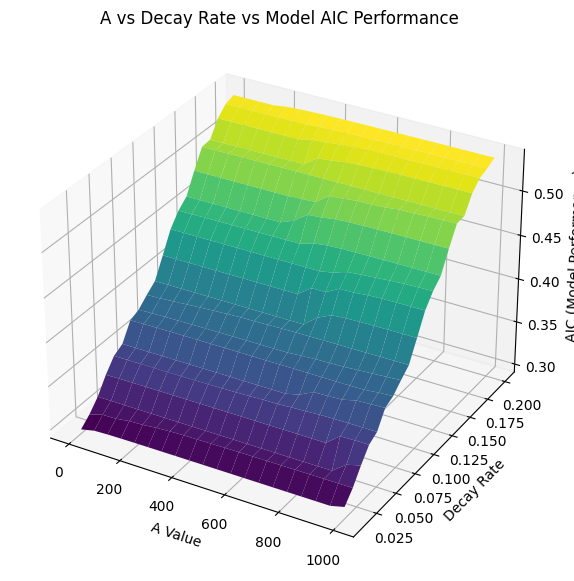

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def grid_search_and_plot(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    # 모든 하이퍼파라미터 조합을 시도하여 결과를 평가
    results_df = evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values)

    # 3D Plot을 위한 배열 생성
    A_vals = results_df['A'].values
    decay_rate_vals = results_df['decay_rate'].values
    aic_vals = results_df['AIC'].values

    # 3D Surface Plot 생성
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # A 값과 decay_rate 값을 meshgrid로 변환
    A_vals_grid, decay_rate_vals_grid = np.meshgrid(A_values, decay_rate_values)
    aic_vals_grid = aic_vals.reshape(len(decay_rate_values), len(A_values))

    # Surface plot
    ax.plot_surface(A_vals_grid, decay_rate_vals_grid, aic_vals_grid, cmap='viridis', edgecolor='none')

    # 축 및 레이블 설정
    ax.set_xlabel('A Value')
    ax.set_ylabel('Decay Rate')
    ax.set_zlabel('AIC (Model Performance)')
    ax.set_title('A vs Decay Rate vs Model AIC Performance')

    # Plot 출력
    plt.show()

# 세밀한 A 값과 decay_rate 값 설정
A_values = np.linspace(0.5, 1000, 20)  # 예시로 A 값을 20개의 구간으로 나눔
decay_rate_values = np.linspace(0.01, 0.2, 20)  # decay_rate도 20개의 구간으로 설정

# Grid search와 plot 호출
grid_search_and_plot(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.551e+18, tolerance: 1.236e+16
  model = cd_fast.enet_coordinate_descent(


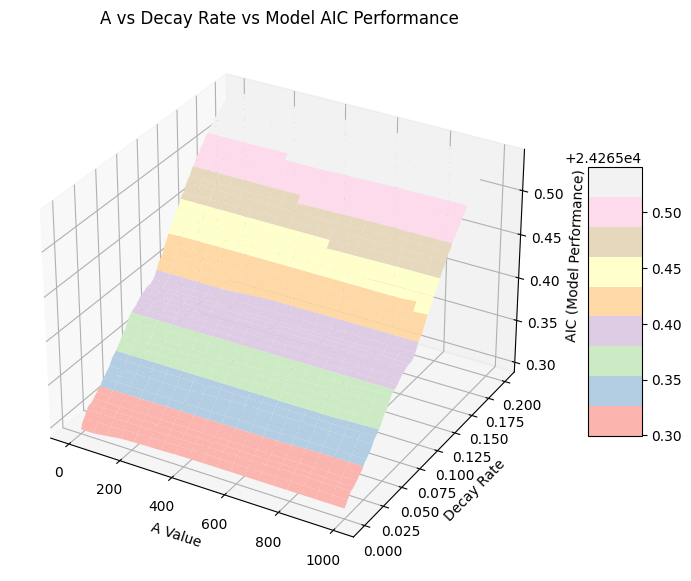

In [96]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def grid_search_and_plot(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    # 모든 하이퍼파라미터 조합을 시도하여 결과를 평가
    results_df = evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values)

    # 3D Plot을 위한 배열 생성
    A_vals = results_df['A'].values
    decay_rate_vals = results_df['decay_rate'].values
    aic_vals = results_df['AIC'].values

    # 3D Surface Plot 생성
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # A 값과 decay_rate 값을 meshgrid로 변환
    A_vals_grid, decay_rate_vals_grid = np.meshgrid(A_values, decay_rate_values)
    aic_vals_grid = aic_vals.reshape(len(decay_rate_values), len(A_values))

    # Surface plot (파스텔 톤의 cmap 적용)
    surf = ax.plot_surface(A_vals_grid, decay_rate_vals_grid, aic_vals_grid, cmap='Pastel1', edgecolor='none')

    # 축 및 레이블 설정
    ax.set_xlabel('A Value')
    ax.set_ylabel('Decay Rate')
    ax.set_zlabel('AIC (Model Performance)')
    ax.set_title('A vs Decay Rate vs Model AIC Performance')

    # 색상 범례 추가
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

    # Plot 출력
    plt.show()

# 세밀한 A 값과 decay_rate 값 설정
A_values = np.linspace(0.5, 1000, 20)  # 예시로 A 값을 20개의 구간으로 나눔
decay_rate_values = np.linspace(0, 0.2, 100)  # decay_rate도 20개의 구간으로 설정

# Grid search와 plot 호출
grid_search_and_plot(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)


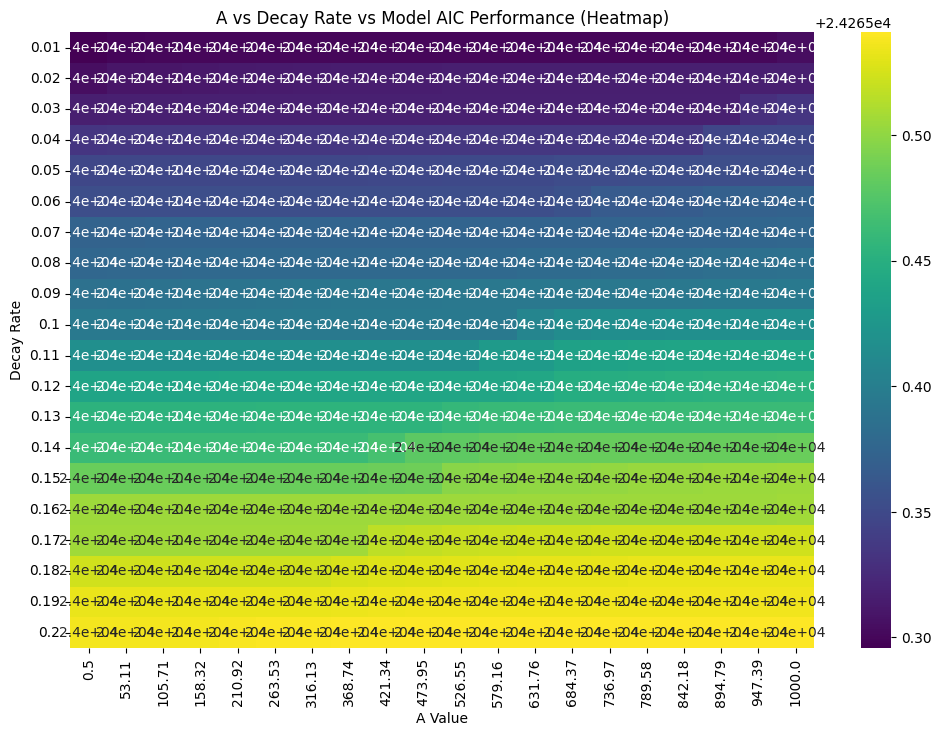

In [93]:
import seaborn as sns

def grid_search_and_heatmap(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values):
    # 모든 하이퍼파라미터 조합을 시도하여 결과를 평가
    results_df = evaluate_exponential_decay_with_oversampling(X_train, X_test, y_train, y_test, feature, A_values, decay_rate_values)

    # Heatmap을 위한 데이터를 reshape
    A_vals = results_df['A'].values
    decay_rate_vals = results_df['decay_rate'].values
    aic_vals = results_df['AIC'].values

    # Reshaping data for heatmap
    aic_vals_grid = aic_vals.reshape(len(decay_rate_values), len(A_values))

    # Heatmap 생성
    plt.figure(figsize=(12, 8))
    sns.heatmap(aic_vals_grid, xticklabels=np.round(A_values, 2), yticklabels=np.round(decay_rate_values, 3), cmap="viridis", annot=True)
    plt.xlabel('A Value')
    plt.ylabel('Decay Rate')
    plt.title('A vs Decay Rate vs Model AIC Performance (Heatmap)')

    # Plot 출력
    plt.show()

# Heatmap 호출
grid_search_and_heatmap(X_train, X_test, y_train, y_test, 'bb_diff_28', A_values, decay_rate_values)


# 번외: Exponential Growth Function